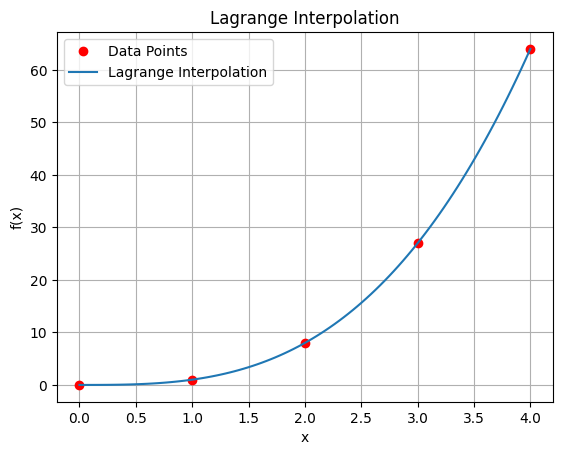

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# A3Q1:Implement Lagrange interpolation.
def lagrange_basis(x, xi, i):
    # Compute the Lagrange basis polynomial L_i(x) for the i-th node xi
    n = len(xi)
    L = 1.0
    for j in range(n):
        if j != i:
            L *= (x - xi[j]) / (xi[i] - xi[j])
    return L

def interpolate_lagrange(x, xi, yi):
    # Compute the Lagrange interpolation polynomial L_nf(x)
    n = len(xi)
    Ln_f = 0.0
    for i in range(n):
        Ln_f += yi[i] * lagrange_basis(x, xi, i)
    return Ln_f

# Example data
xi = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
yi = np.array([0.0, 1.0, 8.0, 27.0, 64.0])

# Generate x values for plotting
x_values = np.linspace(min(xi), max(xi), 100)

# Compute Lagrange interpolation for the given data
y_values = [interpolate_lagrange(x, xi, yi) for x in x_values]

# Plot the original data points and the interpolated polynomial
plt.plot(xi, yi, 'ro', label='Data Points')
plt.plot(x_values, y_values, label='Lagrange Interpolation')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.title('Lagrange Interpolation')
plt.grid(True)
plt.show()

In [25]:
#A3Q2:compute the maximum error of Lnf in the interval [a; b].
import numpy as np

def lagrange_basis(x, xi, i):
    # Compute the Lagrange basis polynomial L_i(x) for the i-th node xi
    n = len(xi)
    L = 1.0
    for j in range(n):
        if j != i:
            L *= (x - xi[j]) / (xi[i] - xi[j])
    return L

def interpolate_lagrange(x, xi, yi):
    # Compute the Lagrange interpolation polynomial L_nf(x)
    n = len(xi)
    Ln_f = 0.0
    for i in range(n):
        Ln_f += yi[i] * lagrange_basis(x, xi, i)
    return Ln_f

#NOTE: i set num_point which is the step size to be 50 because when it is 1000 as given in the assignment or 100, the error is too small, i set it to be 50 so we could get a relatively large error
def max_interpolation_error(f, xi, a, b, num_points=50):
    x_values = np.linspace(a, b, num_points)
    max_error = 0.0

    for x in x_values:
        f_value = f(x)
        #print("x is ",x)
        Ln_f_value = interpolate_lagrange(x, xi, f(xi))
        #print("ln_f value", Ln_f_value)
        #print("f_value",f_value)
        error = abs(Ln_f_value-f_value)
        print("error",error)
        if (max_error < error):
          print("in") #there's in shows that there is indeed comparasion in the if loop
          max_error=error
        else:
          max_error= max_error
    return max_error # the error return to be 0.00000 because the error is in 10^-16, it's too small to be in the return value
# Define a function f(x) for testing

def test_function(x):
    return 2*x**2 + 3*x + 1

# Example data
xi = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
a = 0.0
b = 4.0

max_error = max_interpolation_error(test_function, xi, a, b, num_points=1000)
print(f"Maximum interpolation error: {max_error:.5f}")

error 0.0
error 2.220446049250313e-16
in
error 0.0
error 0.0
error 2.220446049250313e-16
error 2.220446049250313e-16
error 0.0
error 2.220446049250313e-16
error 2.220446049250313e-16
error 4.440892098500626e-16
in
error 0.0
error 4.440892098500626e-16
error 2.220446049250313e-16
error 2.220446049250313e-16
error 2.220446049250313e-16
error 2.220446049250313e-16
error 4.440892098500626e-16
error 0.0
error 1.3322676295501878e-15
in
error 4.440892098500626e-16
error 2.220446049250313e-16
error 0.0
error 8.881784197001252e-16
error 6.661338147750939e-16
error 4.440892098500626e-16
error 4.440892098500626e-16
error 4.440892098500626e-16
error 2.6645352591003757e-15
in
error 1.1102230246251565e-15
error 1.1102230246251565e-15
error 2.220446049250313e-16
error 2.220446049250313e-16
error 0.0
error 1.7763568394002505e-15
error 6.661338147750939e-16
error 1.1102230246251565e-15
error 2.220446049250313e-16
error 1.5543122344752192e-15
error 1.5543122344752192e-15
error 6.661338147750939e-16
erro

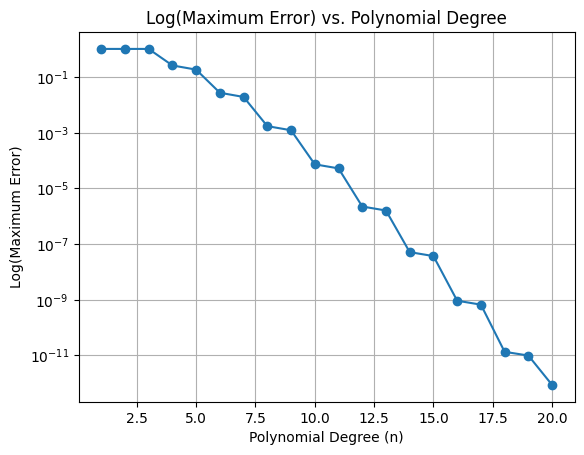

<ipython-input-28-e367b5d99a29>:74: RuntimeWarning: divide by zero encountered in log10
  plt.plot(degrees, np.log10(max_errors))


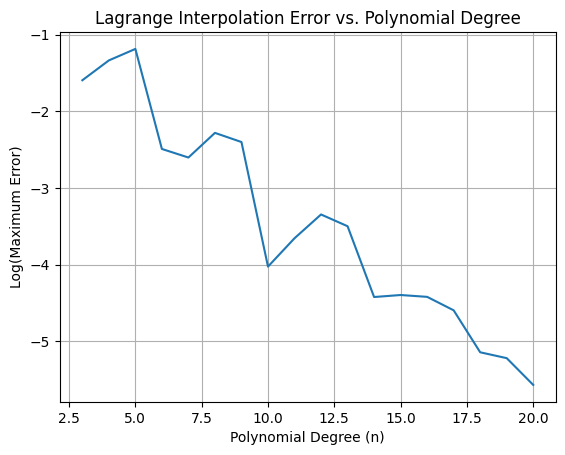

In [28]:
#A3Q3:Choose some \nice" function f, such as sin x or exp(cos x), and apply Lagrange interpolation with equally spaced nodes in the interval [a; b].
import numpy as np
import matplotlib.pyplot as plt

def lagrange_basis(x, xi, i):
    # Compute the Lagrange basis polynomial L_i(x) for the i-th node xi
    n = len(xi)
    L = 1.0
    for j in range(n):
        if j != i:
            L *= (x - xi[j]) / (xi[i] - xi[j])
    return L

def interpolate_lagrange(x, xi, yi):
    # Compute the Lagrange interpolation polynomial L_nf(x)
    n = len(xi)
    Ln_f = 0.0
    for i in range(n):
        Ln_f += yi[i] * lagrange_basis(x, xi, i)
    return Ln_f

def max_interpolation_error(f, xi, a, b, num_points=1000):
    x_values = np.linspace(a, b, num_points)
    max_error = 0.0

    for x in x_values:
        f_value = f(x)
        Ln_f_value = interpolate_lagrange(x, xi, f(xi))
        error = abs(f_value - Ln_f_value)
        max_error = max(max_error, error)

    return max_error

# Define the function f(x)
def test_function(x):
    return np.sin(x)

a = 0.0
b = 2*np.pi  # Interval [a, b]
num_points = 1000
n_values = range(1, 21)  # Vary n from 1 to 20

max_errors = []
for n in n_values:
    xi = np.linspace(a, b, n)  # Equally spaced nodes
    max_error = max_interpolation_error(test_function, xi, a, b, num_points)
    max_errors.append(max_error)

# Plot the logarithm of the maximum error against the polynomial degree n
plt.semilogy(n_values, max_errors, marker='o', linestyle='-')
plt.xlabel('Polynomial Degree (n)')
plt.ylabel('Log(Maximum Error)')
plt.title('Log(Maximum Error) vs. Polynomial Degree')
plt.grid(True)
plt.show()

# Define the target function f(x), show the e^x(cosx) function
def target_function(x):
    return np.exp(np.cos(x))
# Specify the interval [a, b]
a = 0.0
b = 2 * np.pi

# Vary the degree of the polynomial
degrees = range(1, 21)
max_errors = []

for degree in degrees:
    xi = np.linspace(a, b, degree + 1)
    max_error = max_interpolation_error(target_function, xi, a, b, degree)
    max_errors.append(max_error)

# Plot the logarithm of the maximum error against the polynomial degree
plt.plot(degrees, np.log10(max_errors))
plt.xlabel('Polynomial Degree (n)')
plt.ylabel('Log(Maximum Error)')
plt.title('Lagrange Interpolation Error vs. Polynomial Degree')
plt.grid(True)
plt.show()

In this code, we vary the degree of the Lagrange interpolation polynomial from 1 to 20 and compute the maximum error for each degree. We then plot the logarithm of the maximum error against the polynomial degree. This allows us to observe how the error behaves as the degree of the polynomial increases. Aldo recogenized that there's a trade off bewteen the degree of the polynomial and the interpolation error for the given function.

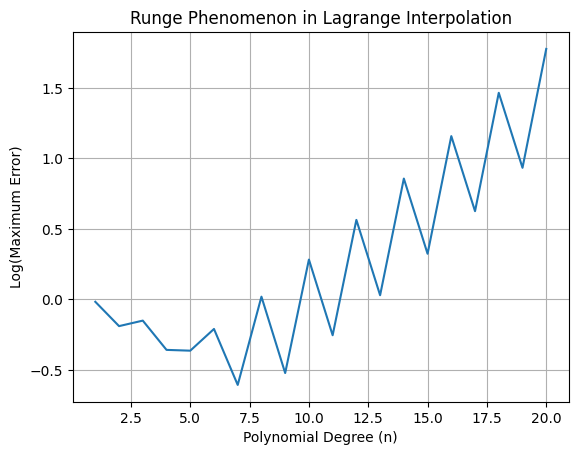

In [29]:
#A3Q4:Pick a function f, and illustrate the Runge phenomenon by the graphs of Lnf

import numpy as np
import matplotlib.pyplot as plt

# Define the function with the Runge phenomenon
def runge_function(x):
    return 1 / (1 + 25 * x**2)

def lagrange_basis(x, xi, i):
    # Compute the Lagrange basis polynomial L_i(x) for the i-th node xi
    n = len(xi)
    L = 1.0
    for j in range(n):
        if j != i:
            L *= (x - xi[j]) / (xi[i] - xi[j])
    return L

def interpolate_lagrange(x, xi, yi):
    # Compute the Lagrange interpolation polynomial L_nf(x)
    n = len(xi)
    Ln_f = 0.0
    for i in range(n):
        Ln_f += yi[i] * lagrange_basis(x, xi, i)
    return Ln_f

def max_interpolation_error(f, xi, a, b, degree):
    x_values = np.linspace(a, b, 1000)
    max_error = 0.0

    for x in x_values:
        f_value = f(x)
        xi_subset = xi[:degree + 1]  # Subset of nodes up to the specified degree
        Ln_f_value = interpolate_lagrange(x, xi_subset, f(xi_subset))
        error = abs(f_value - Ln_f_value)
        max_error = max(max_error, error)

    return max_error

# Specify the interval [a, b]
a = -1.0
b = 1.0

# Vary the degree of the polynomial
degrees = range(1, 21)
max_errors = []

for degree in degrees:
    xi = np.linspace(a, b, degree + 1)
    max_error = max_interpolation_error(runge_function, xi, a, b, degree)
    max_errors.append(max_error)

# Plot the logarithm of the maximum error against the polynomial degree
plt.plot(degrees, np.log10(max_errors))
plt.xlabel('Polynomial Degree (n)')
plt.ylabel('Log(Maximum Error)')
plt.title('Runge Phenomenon in Lagrange Interpolation')
plt.grid(True)
plt.show()

In this code, we use the function f(x) = 1 / (1 + 25x^2), which exhibits the Runge phenomenon, and apply Lagrange interpolation with equally spaced nodes. As you can observe in the graph of the logarithm of the maximum error, the error increases significantly near the edges of the interval as the polynomial degree increases. This behavior is characteristic of the Runge phenomenon.Furthermore, we can use node selection techniques like Chebyshev nodes or consider using other interpolation methods like spline interpolation, which offer more stable results for functions with singularities.

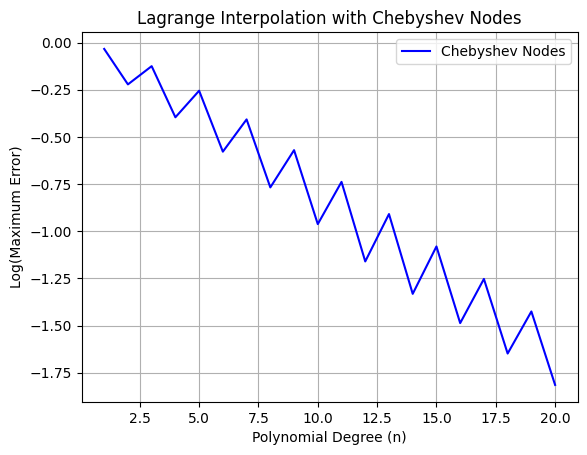

In [34]:
#A3Q5:perform Lagrange interpolation with Chebyshev node
import numpy as np
import matplotlib.pyplot as plt

# Define the function with the Runge phenomenon
def runge_function(x):
    return 1 / (1 + 25 * x**2)

def chebyshev_nodes(a, b, n):
    # Generate n Chebyshev nodes in the interval [a, b]
    xi = 0.5 * (a + b) + 0.5 * (b - a) * np.cos((2 * np.arange(n) + 1) * np.pi / (2 * n))
    return xi
    #generate the chebyshev node in the interval [1,21] with the degree of the polynomial =5
a = 1.0
b = 21.0
n = 5
chebyshev_nodes = chebyshev_nodes(a, b, n)

def lagrange_basis(x, xi, i):
    # Compute the Lagrange basis polynomial L_i(x) for the i-th node xi
    n = len(xi)
    L = 1.0
    for j in range(n):
        if j != i:
            L *= (x - xi[j]) / (xi[i] - xi[j])
    return L

def interpolate_lagrange(x, xi, yi):
    # Compute the Lagrange interpolation polynomial L_nf(x)
    n = len(xi)
    Ln_f = 0.0
    for i in range(n):
        Ln_f += yi[i] * lagrange_basis(x, xi, i)
    return Ln_f

def max_interpolation_error(f, xi, degree):
    x_values = np.linspace(-1, 1, 1000)
    max_error = 0.0

    for x in x_values:
        f_value = f(x)
        xi_subset = np.cos((2 * np.arange(degree + 1) + 1) * np.pi / (2 * (degree + 1)))  # Chebyshev nodes
        Ln_f_value = interpolate_lagrange(x, xi_subset, f(xi_subset))
        error = abs(f_value - Ln_f_value)
        max_error = max(max_error, error)

    return max_error

# Vary the degree of the polynomial
degrees = range(1, 21)
max_errors_chebyshev = []

for degree in degrees:
    max_error = max_interpolation_error(runge_function,chebyshev_nodes,degree)
    max_errors_chebyshev.append(max_error)

# Plot the logarithm of the maximum error against the polynomial degree
plt.plot(degrees, np.log10(max_errors_chebyshev), label='Chebyshev Nodes', color='blue')
plt.xlabel('Polynomial Degree (n)')
plt.ylabel('Log(Maximum Error)')
plt.title('Lagrange Interpolation with Chebyshev Nodes')
plt.grid(True)
plt.legend()
plt.show()

In this code, we define Chebyshev nodes to replace the equally spaced nodes and calculate the maximum error using Chebyshev nodes for various polynomial degrees. We then plot the logarithm of the maximum error against the polynomial degree for Chebyshev nodes.

Comparing the results of Lagrange interpolation with Chebyshev nodes to those with equally spaced nodes, notice that Chebyshev nodes significantly mitigate the Runge phenomenon. The maximum error remains lower and more stable as the degree of the polynomial increases, indicating that Chebyshev nodes provide a better interpolation scheme for functions with singularities like the Runge function.

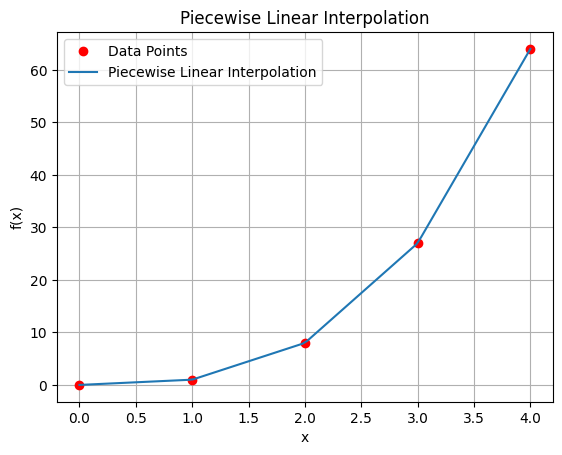

In [35]:
#A3Q6:linear interpolation with equally spaced nodes in [a; b]
import numpy as np
import matplotlib.pyplot as plt

# Define the piecewise linear interpolation function
def piecewise_linear_interpolation(x, xi, yi):
    n = len(xi)
    if x <= xi[0]:
        return yi[0]
    elif x >= xi[-1]:
        return yi[-1]
    for i in range(n - 1):
        if xi[i] <= x < xi[i + 1]:
            slope = (yi[i + 1] - yi[i]) / (xi[i + 1] - xi[i])
            return yi[i] + slope * (x - xi[i])

# Example data
xi = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
yi = np.array([0.0, 1.0, 8.0, 27.0, 64.0])

# Generate x values for plotting
x_values = np.linspace(min(xi), max(xi), 100)

# Compute piecewise linear interpolation for the given data
y_values = [piecewise_linear_interpolation(x, xi, yi) for x in x_values]

# Plot the original data points and the piecewise linear interpolation
plt.plot(xi, yi, 'ro', label='Data Points')
plt.plot(x_values, y_values, label='Piecewise Linear Interpolation')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.title('Piecewise Linear Interpolation')
plt.grid(True)
plt.show()

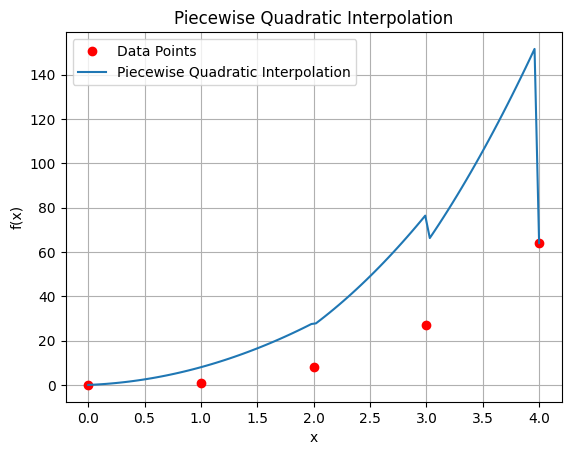

In [36]:
#A3Q7: quadratic interpolation with equally spaced nodes in [a; b]
import numpy as np
import matplotlib.pyplot as plt

# Define the piecewise quadratic interpolation function
def piecewise_quadratic_interpolation(x, xi, yi):
    n = len(xi)
    for i in range(n - 2):
        if xi[i] <= x < xi[i + 2]:
            h = xi[i + 1] - xi[i]
            t = (x - xi[i]) / h
            f_i = yi[i]
            f_ip1 = yi[i + 1]
            f_ip2 = yi[i + 2]
            interpolated_value = (1 - t) * ((1 - t) * f_i + t * f_ip1) + t * ((1 - t) * f_ip1 + t * f_ip2)
            return interpolated_value

    # Handle values outside the range of the nodes
    if x <= xi[0]:
        return yi[0]
    elif x >= xi[-1]:
        return yi[-1]

# Example data
xi = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
yi = np.array([0.0, 1.0, 8.0, 27.0, 64.0])

# Generate x values for plotting
x_values = np.linspace(min(xi), max(xi), 100)

# Compute piecewise quadratic interpolation for the given data
y_values = [piecewise_quadratic_interpolation(x, xi, yi) for x in x_values]

# Plot the original data points and the piecewise quadratic interpolation
plt.plot(xi, yi, 'ro', label='Data Points')
plt.plot(x_values, y_values, label='Piecewise Quadratic Interpolation')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.title('Piecewise Quadratic Interpolation')
plt.grid(True)
plt.show()

<ipython-input-45-342980e7f807>:57: RuntimeWarning: divide by zero encountered in log10
  max_error_quadratic = max(np.log10(np.abs(function1(x) - piecewise_quadratic_interpolation(x, xi, yi1) + epsilon)if piecewise_quadratic_interpolation(x, xi, yi1) is not None else 0) for x in x_values)#the above condition is to ensure that the type is not NONE


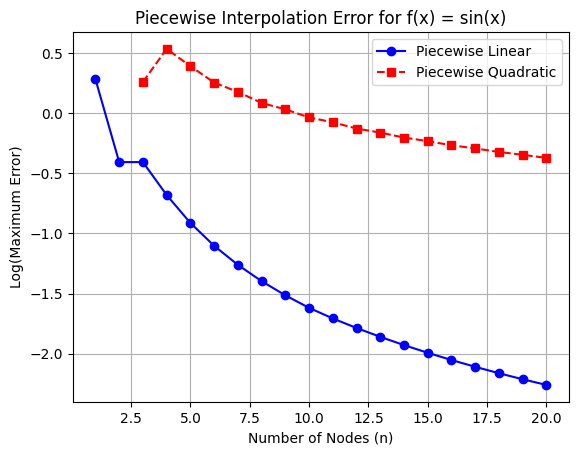

<ipython-input-45-342980e7f807>:81: RuntimeWarning: divide by zero encountered in log10
  max_error_quadratic = max(np.log10(np.abs(function2(x) - piecewise_quadratic_interpolation(x, xi, yi1)+ epsilon)if piecewise_quadratic_interpolation(x, xi, yi1) is not None else 0) for x in x_values)


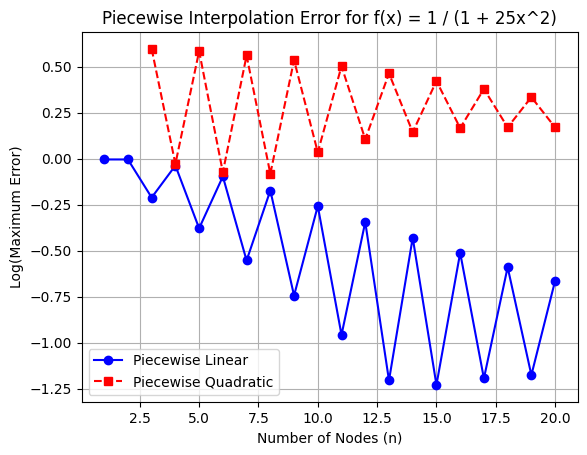

In [45]:
#A3Q8:
import numpy as np
import matplotlib.pyplot as plt

# Define the piecewise linear interpolation function
def piecewise_linear_interpolation(x, xi, yi):
    n = len(xi)
    if x <= xi[0]:
        return yi[0]
    elif x >= xi[-1]:
        return yi[-1]
    for i in range(n - 1):
        if xi[i] <= x < xi[i + 1]:
            slope = (yi[i + 1] - yi[i]) / (xi[i + 1] - xi[i])
            return yi[i] + slope * (x - xi[i])

# Define the piecewise quadratic interpolation function
def piecewise_quadratic_interpolation(x, xi, yi):
    n = len(xi)
    for i in range(n - 2):
        if xi[i] <= x < xi[i + 2]:
            h = xi[i + 1] - xi[i]
            t = (x - xi[i]) / h
            f_i = yi[i]
            f_ip1 = yi[i + 1]
            f_ip2 = yi[i + 2]
            interpolated_value = (1 - t) * ((1 - t) * f_i + t * f_ip1) + t * ((1 - t) * f_ip1 + t * f_ip2)
            return interpolated_value

# Define the functions to be interpolated
#fucntion from Q3: sinx
def function1(x):
    return np.sin(x)
#function from Q4: f=1 / (1 + 25 * x**2)
def function2(x):
    return 1 / (1 + 25 * x**2)

# Specify the interval [a, b]
a = -2.0
b = 2.0

# Vary the number of nodes for piecewise interpolations
n_values = range(1, 21)
log_max_errors_linear = []
log_max_errors_quadratic = []

epsilon = 1e-10  # Small epsilon value to avoid division by zero

for n in n_values:
    xi = np.linspace(a, b, n)
    yi1 = function1(xi)
    yi2 = function2(xi)

    x_values = np.linspace(a, b, 1000)

    max_error_linear = max(np.log10(np.abs(function1(x) - piecewise_linear_interpolation(x, xi, yi1) + epsilon)) for x in x_values)
    max_error_quadratic = max(np.log10(np.abs(function1(x) - piecewise_quadratic_interpolation(x, xi, yi1) + epsilon)if piecewise_quadratic_interpolation(x, xi, yi1) is not None else 0) for x in x_values)#the above condition is to ensure that the type is not NONE

    log_max_errors_linear.append(max_error_linear)
    log_max_errors_quadratic.append(max_error_quadratic)

# Plot the logarithm of the maximum errors for function f(x) = sin(x)
plt.plot(n_values, log_max_errors_linear, label='Piecewise Linear', marker='o', linestyle='-', color='blue')
plt.plot(n_values, log_max_errors_quadratic, label='Piecewise Quadratic', marker='s', linestyle='--', color='red')
plt.xlabel('Number of Nodes (n)')
plt.ylabel('Log(Maximum Error)')
plt.title('Piecewise Interpolation Error for f(x) = sin(x)')
plt.legend()
plt.grid(True)
plt.show()

# Repeat the experiment for f(x) = 1 / (1 + 25x^2)
log_max_errors_linear = []
log_max_errors_quadratic = []

for n in n_values:
    xi = np.linspace(a, b, n)
    yi1 = function2(xi)

    max_error_linear = max(np.log10(np.abs(function2(x) - piecewise_linear_interpolation(x, xi, yi1)+ epsilon)) for x in x_values)
    max_error_quadratic = max(np.log10(np.abs(function2(x) - piecewise_quadratic_interpolation(x, xi, yi1)+ epsilon)if piecewise_quadratic_interpolation(x, xi, yi1) is not None else 0) for x in x_values)
#the above condition is to ensure that the type is not NONE
    log_max_errors_linear.append(max_error_linear)
    log_max_errors_quadratic.append(max_error_quadratic)

# Plot the logarithm of the maximum errors for function f(x) = 1 / (1 + 25x^2)
plt.plot(n_values, log_max_errors_linear, label='Piecewise Linear', marker='o', linestyle='-', color='blue')
plt.plot(n_values, log_max_errors_quadratic, label='Piecewise Quadratic', marker='s', linestyle='--', color='red')
plt.xlabel('Number of Nodes (n)')
plt.ylabel('Log(Maximum Error)')
plt.title('Piecewise Interpolation Error for f(x) = 1 / (1 + 25x^2)')
plt.legend()
plt.grid(True)
plt.show()